In [4]:
# LandownerElkTags
import tabula
import pandas as pd
import requests
import io
import numpy as np
from publictrust.wildlife import parse_pdf_to_dataframe, create_interactive_map
import geopandas as gpd
from pathlib import Path
import matplotlib.pyplot as plt


## READ THE 2025 WGFD LANDOWNER TAG QUOTA DATA

In [ ]:

landownertags2025_url = "https://wgfd.wyo.gov/media/32688/download?inline" # 2025 Landowner Elk Tag Quotas PDF

# Get the DataFrame
landowner_tags = parse_pdf_to_dataframe(landownertags2025_url)

if not landowner_tags.empty:
    # Determine percentage of tags allocated to the landowner
    landowner_tags['pct_landowner'] = landowner_tags['Issued']/landowner_tags['Quota'] * 100
    ls_tag_dist = []
    for i, row in landowner_tags.iterrows():
        ls_tag_dist.append(f"{row['Issued']} of {row['Quota']}")
    landowner_tags['landowner_tags_per_total'] = ls_tag_dist
else:
    print("PROBLEM WITH READING DATA FROM THE PDF FILE. CANNOT PROCEED!")

Successfully parsed PDF and created DataFrame.


In [10]:
# Review summaries of landowner & resident quota data used in the maps:
print(landowner_tags)

   Hunt_Area Type     Description  Quota  Issued  PP  Applicants  \
0          1    1         ANY ELK     84       2   1           0   
1          1    4  ANTLERLESS ELK     63       0   0           0   
2          6    1         ANY ELK     42       0   0           0   
3          6    4  ANTLERLESS ELK     21       0   0           0   
4          7    1         ANY ELK   1260     253   0           0   
..       ...  ...             ...    ...     ...  ..         ...   
25       123    4  ANTLERLESS ELK     90       0   0           0   
26       124    1         ANY ELK     84      24   0           0   
27       124    4  ANTLERLESS ELK    126       0   0           0   
28       125    1         ANY ELK    168       3   0           0   
29       GEN  NaN         GENERAL   9999       0   0           0   

    pct_landowner landowner_tags_per_total  
0        2.380952                  2 of 84  
1        0.000000                  0 of 63  
2        0.000000                  0 of 42  
3  

## Visualize the distribution of resident landowner tags in 2025
How many tags went to landowners across all limited quota hunt areas?
The following plots depict
1) The distribution of all tag types
2) The distribution of type 1 tags
3) The distribution of type 2 tags

Text(0, 0.5, 'Total Hunt Areas')

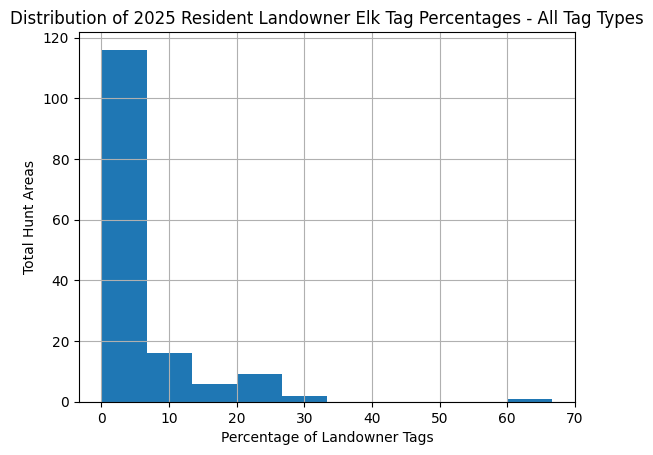

In [ ]:
ax = landowner_tags['pct_landowner'].hist()
# Set the title and labels
ax.set_title("Distribution of 2025 Resident Landowner Elk Tag Percentages - All Tag Types")
ax.set_xlabel("Percentage of Landowner Tags")
ax.set_ylabel("Total Hunt Areas")

Text(0, 0.5, 'Total Hunt Areas')

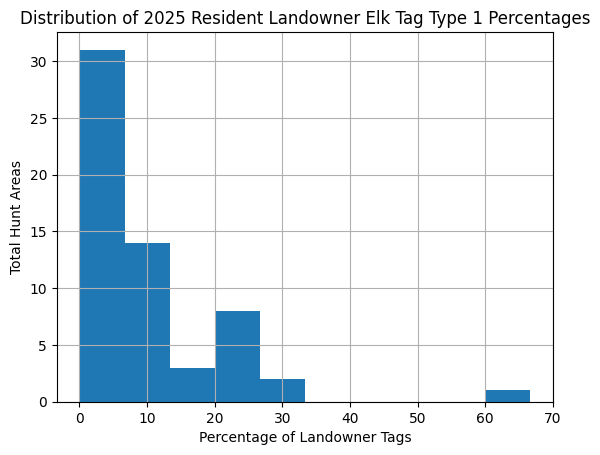

In [8]:
type1_landowner_tags = landowner_tags[landowner_tags['Type']=='1']
# Capture the axes object returned by the plot
ax = type1_landowner_tags['pct_landowner'].hist()

# Set the title and labels
ax.set_title("Distribution of 2025 Resident Landowner Elk Tag Type 1 Percentages")
ax.set_xlabel("Percentage of Landowner Tags")
ax.set_ylabel("Total Hunt Areas")

Text(0, 0.5, 'Total Hunt Areas')

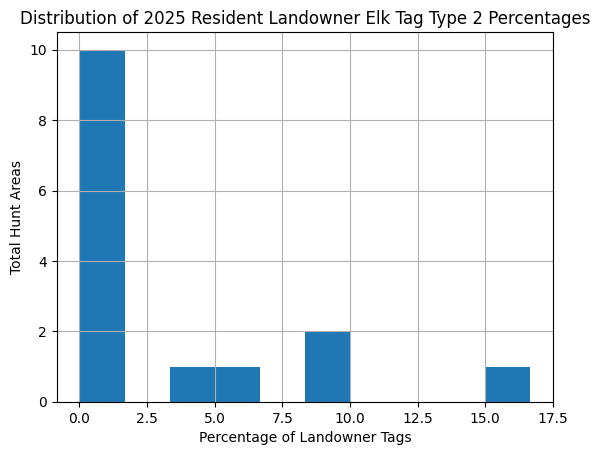

In [7]:
type2_landowner_tags = landowner_tags[landowner_tags['Type']=='2']
ax = type2_landowner_tags['pct_landowner'].hist()
# Set the title and labels
ax.set_title("Distribution of 2025 Resident Landowner Elk Tag Type 2 Percentages")
ax.set_xlabel("Percentage of Landowner Tags")
ax.set_ylabel("Total Hunt Areas")

## MAKE MAPS
By combining landowner tag data with hunt area map data

In [3]:
# Read in the Wyoming G&F Elk Hunt Areas Map
gdf_ha = gpd.read_file("~/Documents/personal/BHA/data_in/gpkg/ElkHuntAreas_5201991498639818979.gpkg")
gdf_ha['HUNTAREA'] = gdf_ha['HUNTAREA'].astype(str).str.replace(".0","")


In [ ]:
# Combine map data with the landowner tags data
gdf_ha_cmbo = gdf_ha.merge(landowner_tags,left_on='HUNTAREA', right_on='Hunt_Area')
gdf_cmbo_type1 = gdf_ha_cmbo[gdf_ha_cmbo['Type']=='1'] # Filter to the type 1 tags
gdf_cmbo_type2 = gdf_ha_cmbo[gdf_ha_cmbo['Type']=='2'] # Filter to the type 2 tags


    HUNTAREA  HERDUNIT                     HERDNAME      SqMiles  \
13        41     211.0               Medicine Lodge   665.666575   
35        61     216.0                         Cody   384.616829   
42        63     214.0                   Gooseberry   365.901484   
59        78     102.0                      Jackson    70.883282   
61       122     743.0                   Pine Ridge  1275.064427   
73        19     741.0  Laramie Peak/Muddy Mountain   743.255136   
82        22     639.0                       Ferris   325.441448   
89        11     533.0                  Snowy Range   692.057934   
108      111     639.0                       Ferris   918.699937   
114       95     107.0            Upper Green River   322.368161   
121      100     426.0                    Steamboat  3735.240310   
131       16     534.0             Shirley Mountain  1756.201540   
134        7     741.0  Laramie Peak/Muddy Mountain  4041.861634   
139       51     217.0                 Clark's F

In [5]:
create_interactive_map(gdf=gdf_cmbo_type1, output_html = "~/Documents/personal/BHA/data_out/updated_elk2025_landowner_type1_bha.html", map_title = '2025 Type 1 Resident Landowner Elk Tag Allocations',img_path = "~/Documents/personal/BHA/data_in/BHALOGOBLACK.clear.png")

Reprojecting data to WGS84 (EPSG:4326)...
Adding polygons and hover interactions...


/Users/guylitt/git/public_trust_wildlife/publictrust/wildlife.py:128: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_lat = gdf.geometry.centroid.y.mean()
/Users/guylitt/git/public_trust_wildlife/publictrust/wildlife.py:129: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_lon = gdf.geometry.centroid.x.mean()


Adding labels...
Map successfully generated: /Users/guylitt/Documents/personal/BHA/data_out/updated_elk2025_landowner_type1_bha.html
